#           <font color=red>           Measures of Dispersion</font>

Measures of dispersion are values that describe how the data varies. It gives us a sense of how much the data tends to diverge from the typical value. Aka measures of variability, they quantify the spread of data points.The major measures of dispersion include 

__*range,*__

__*percentiles,*__ 

__*inter-quentile range,*__

__*variance,*__

__*standard deviation,*__

__*skewness and kurtosis*__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

## additional statistics modules
import scipy.stats as sp
import statistics

In [2]:
Movies = pd.read_csv("HighestGrossingMovies.csv")         #Dataset of the Top10 highest-grossing films as of 2019 (adjusted for inflation)
                                                          #5 columns (Movie, Director, Year, Budget, Gross) and 10 rows
Movies.describe()


,Year,Budget_million$,Gross_million$
count,10.000000,10.000000,10.000000
mean,1982.400000,115.660000,2771.400000
std,26.953458,142.739991,493.903994
min,1939.000000,3.900000,2202.000000
25%,1965.000000,10.625000,2389.250000
50%,1979.500000,12.000000,2673.500000
75%,2006.000000,227.750000,3071.500000
max,2019.000000,356.000000,3706.000000


## <font color=crimson>Range</font>

![](https://cdn.corporatefinanceinstitute.com/assets/range1.png)


The range gives a quick sense of the spread of the distribution to those who require only a rough indication of the data. There are some disadvantages of using the range as a measure of spread. One being it does not give any information of the data in between maximum and minimum. Also, the range is very sensitive to extreme values. Let's calculate the range for the budget of the Top10 highest-grossing films: 

In [3]:
Budget = Movies['Budget_million$']

In [4]:
# via the numpy library:
Budget = Movies['Budget_million$']
range2 = np.ptp(Budget) #ptp stands for Peak To Peak
print("The range of the budget of the Top10 highest-grossing films is ",range2,"million USD")

The range of the budget of the Top10 highest-grossing films is  352.1 million USD


________________


## <font color=crimson>Percentiles and Quartiles</font>

![](https://sigmamagic.com/blogs/images/quartiles.jpg)

___________


A measure which indicates the value below which a given percentage of points in a dataset fall. The sample 𝑝 percentile is the element in the dataset such that 𝑝% of the elements in the dataset are less than or equal to that value. Also, (100 − 𝑝)% of the elements are greater than or equal to that value. For example, median represents the 50th percentile. Similarly, we can have 0th percentile representing the minimum and 100th percentile representing the maximum of all data points. Percentile gives the relative position of a particular value within the dataset. It also helps in comparing the data sets which have different means and deviations.
Each dataset has three quartiles, which are the percentiles that divide the dataset into four parts:

- The first quartile (Q1) is the sample 25th percentile. It divides roughly 25% of the smallest items from the rest of the dataset.
- The second quartile Q2) is the sample 50th percentile or the median. Approximately 25% of the items lie between the first and second quartiles and another 25% between the second and third quartiles.
- The third quartile (Q3) is the sample 75th percentile. It divides roughly 25% of the largest items from the rest of the dataset.

In [5]:
#via Pandas:
p10n = Budget.quantile(0.10) #returns the 10th percentile - notice the difference from Numpy
print("The 10th percentile of the budget of the Top10 highest-grossing films is ",p10n)


The 10th percentile of the budget of the Top10 highest-grossing films is  7.77


In [6]:
#via Numpy:
p10 = np.percentile(Budget, 10) #returns the 10th percentile
print("The 10th percentile of the budget of the Top10 highest-grossing films is ",p10)
p4070 = np.percentile(Budget, [10,40,70]) #returns the 40th and 70th percentile
print("The 40th and 70th percentile of the budget of the Top10 highest-grossing films are ",p4070)

The 10th percentile of the budget of the Top10 highest-grossing films is  7.77
The 40th and 70th percentile of the budget of the Top10 highest-grossing films are  [  7.77  11.   211.1 ]


## <font color=crimson>InterQuartile Range (IQR)</font>

![](https://cdn.scribbr.com/wp-content/uploads/2020/09/iqr_quartiles.png)


IQR is the difference between the third quartile and the first quartile (Q3-Q1). The interquartile range is a better option than range because it is not affected by outliers. It removes the outliers by just focusing on the distance within the middle 50% of the data.

In [7]:
#via Numpy:
IQR1 = np.percentile(Budget, 75) -np.percentile(Budget, 25)    #returns the IQR = Q3-Q1 = P75-P25
print("The IQR of the budget of the Top10 highest-grossing films is ",IQR1)



The IQR of the budget of the Top10 highest-grossing films is  217.125


In [ ]:
#via scipy.stats:

IQR2 = sp.iqr(Budget)    #returns the IQR- Can be used for other percentile differences as well >> iqr(object, rng=(p1, p2))
print("The IQR of the budget of the Top10 highest-grossing films is ",IQR2)

## <font color=crimson>The Five-number Summary</font>

A five-number summary is especially useful in descriptive analyses or during the preliminary investigation of a large data set. A summary consists of five values: the most extreme values in the data set (the maximum and minimum values), the lower and upper quartiles, and the median. Five-number summary can be used to describe any data distribution. Boxplots are extremely useful graphical representation of the 5-number summary that we will discuss later.

In [8]:
Budget.describe() 
#Budget.hist(bins=100)#Remember this jewel from Pandas? -It directly return the 5-number summary AND MORE!

count     10.000000
mean     115.660000
std      142.739991
min        3.900000
25%       10.625000
50%       12.000000
75%      227.750000
max      356.000000
Name: Budget_million$, dtype: float64

Boxplots are extremely useful graphical representation of the 5-number summary. It can show the range, interquartile range, median, mode, outliers, and all quartiles.

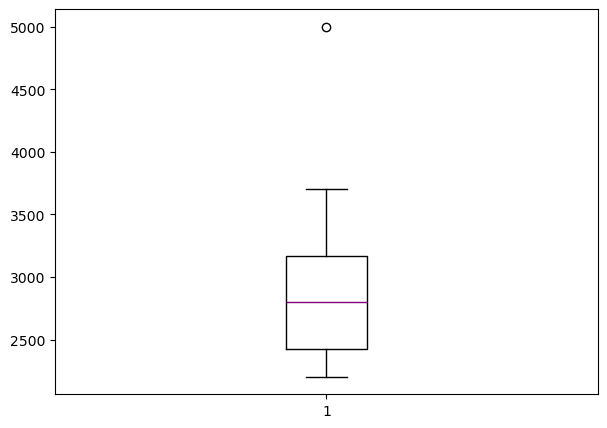

In [9]:
 #Required for the plot

gross = [3706,3257,3081,3043,2798,2549,2489,2356,2233,2202,5000] #same data + an outlier: 5000

fig = plt.figure(figsize =(7, 5))
plt.boxplot(gross,medianprops={'linewidth': 1, 'color': 'purple'})

plt.show()

To read more about the 5-number summary, check these out:
- "Find a Five-Number Summary in Statistics: Easy Steps"
, available @ https://www.statisticshowto.com/how-to-find-a-five-number-summary-in-statistics/

- "The Five-Number Summary"
, available @ https://www.purplemath.com/modules/boxwhisk2.htm

- "What Is the 5 Number Summary?"
by __*Courtney Taylor*__, available @ https://www.statisticshowto.com/probability-and-statistics/statistics-definitions/mean-median-mode/

## <font color=crimson>Variance</font>

![](https://miro.medium.com/max/2376/1*r9empMdWjpMaftsp__4lKw.png)


The sample variance quantifies the spread of the data. It shows numerically how far the data points are from the mean. The observations may or may not be meaningful if observations in data sets are highly spread. 

![](https://miro.medium.com/max/666/0*ovSFlxj9RJMgtQoX.png)

Note that if we are working with the entire population (and not the sample), the denominator should be "n" instead of "n-1".

Let's calculate the variance for budget of the Top10 highest-grossing films.

In [10]:
# via the Statistics library:

var2 = statistics.variance(Budget)
print("The variance of the budget of the Top10 highest-grossing films is ",var2)

The variance of the budget of the Top10 highest-grossing films is  20374.70488888889


## <font color=crimson>Standard Deviation</font>

The sample standard deviation is another measure of data spread. It’s connected to the sample variance, as standard deviation, 𝑠, is the positive square root of the sample variance. The standard deviation is often more convenient than the variance because it has the same unit as the data points.



In [ ]:
# via the Statistics library:

sd2 = statistics.stdev(Budget)
print("The standard deviation of the budget of the Top10 highest-grossing films is ",sd2,"million USD")

## <font color=crimson>Skewness</font>
![](https://library.douglascollege.ca/sites/default/files/Skewness.jpg)


The sample skewness measures the asymmetry of a data sample. There are several mathematical definitions of skewness. The Fisher-Pearson standardized moment coefficient is calculated by using mean, median and standard deviation of the data. 

![](https://miro.medium.com/max/560/1*B-n9Ujb_IPggKO9P52jrDA.png)

Usually, negative skewness values indicate that there’s a dominant tail on the left side. Positive skewness values correspond to a longer or fatter tail on the right side. If the skewness is close to 0 (for example, between −0.5 and 0.5), then the dataset is considered quite symmetrical.

In [11]:

# via the scipy.stats library:

skew2 = sp.skew(Budget, bias=False)
print("The skewness of the budget of the Top10 highest-grossing films is ",skew2)



The skewness of the budget of the Top10 highest-grossing films is  0.763654749052816


In [12]:
# via the Pandas library:

skew3 = Budget.skew()
print("The skewness of the budget of the Top10 highest-grossing films is ",skew3)

The skewness of the budget of the Top10 highest-grossing films is  0.763654749052816


## <font color=crimson>Kurtosis</font>

![](https://excelrcom.b-cdn.net/assets/admin/ckfinder/userfiles/images/tableau1/tableau2/tableau3/tableau4/tableau5/tableau6/skewness-kurtosis_1JPG-.jpg)



Kurtosis describes the peakedness of the distribution. In other words, Kurtosis identifies whether the tails of a given distribution contain extreme values. While Skewness essentially measures the symmetry of the distribution, kurtosis determines the heaviness of the distribution tails.

![](https://miro.medium.com/max/2220/1*-UQjlHtFyW6m5gcyZ6db2A.png)

If the distribution is tall and thin it is called a leptokurtic distribution. Values in a leptokurtic distribution are near the mean or at the extremes. A flat distribution where the values are moderately spread out (i.e., unlike leptokurtic) is called platykurtic distribution. A distribution whose shape is in between a leptokurtic distribution and a platykurtic distribution is called a mesokurtic distribution. 

In [ ]:
# via the scipy.stats library:

Kurt = scipy.stats.kurtosis(Budget)
print("The kurtosis of the budget of the Top10 highest-grossing films is ",Kurt) #a platykurtic distribution | the tails are heavy


To read more about skewness and kurtosis, check these out:
- "Measures of Skewness and Kurtosis"
, available @ https://www.itl.nist.gov/div898/handbook/eda/section3/eda35b.htm#:~:text=Skewness%20is%20a%20measure%20of,relative%20to%20a%20normal%20distribution.

- "Are the Skewness and Kurtosis Useful Statistics?"
, available @ https://www.spcforexcel.com/knowledge/basic-statistics/are-skewness-and-kurtosis-useful-statistics

- "Skew and Kurtosis: 2 Important Statistics terms you need to know in Data Science"
by __*Diva Dugar*__, available @ https://codeburst.io/2-important-statistics-terms-you-need-to-know-in-data-science-skewness-and-kurtosis-388fef94eeaa

- "Measures of Shape: Skewness and Kurtosis"
by __*Stan Brown*__, available @ https://brownmath.com/stat/shape.htm

![](https://media2.giphy.com/media/5nj4ZZWl6QwneEaBX4/source.gif) <br>

*Parts of this notebook were inspired by:* 


- __"Descriptive statistics with Python-NumPy"__ by __*Rashmi Jain*__, available @ https://www.hackerearth.com/blog/developers/descriptive-statistics-python-numpy/.

- __"Python Statistics Fundamentals: How to Describe Your Data"__ by __*Mirko Stojiljković *__, available @ https://realpython.com/python-statistics/.

- __"A Quick Guide on Descriptive Statistics using Pandas and Seaborn"__ by __*Bee Guan Teo*__, available @ https://towardsdatascience.com/a-quick-guide-on-descriptive-statistics-using-pandas-and-seaborn-2aadc7395f32.

- __"Tutorial: Basic Statistics in Python — Descriptive Statistics"__ , available @ https://www.dataquest.io/blog/basic-statistics-with-python-descriptive-statistics/.

*Here are some great reads on this topic:* 
- __"Python Statistics Fundamentals: How to Describe Your Data"__ by __Mirko Stojiljković__ available at *https://realpython.com/python-statistics/* <br>
- __"Introduction to Descriptive Statistics and Probability for Data Science"__ by __Abhishek Kumar__ available at *https://towardsdatascience.com/intro-to-descriptive-statistics-and-probability-for-data-science-8effec826488*<br>
- __"Statistics for Data Science — A beginners guide to Descriptive Statistics in Python"__ by __Angel Das__ available at *https://towardsdatascience.com/statistics-for-data-science-a-beginners-guide-to-descriptive-statistics-in-python-9e0daa30809a*<br>
- __"Interpreting Data Using Descriptive Statistics with Python"__ by __Deepika Singh__ available at *https://www.pluralsight.com/guides/interpreting-data-using-descriptive-statistics-python*<br>


*Here are some great videos on these topics:* 
- __"Descriptive Statistics Using Scipy , Numpy and Pandas in Python - Tutorial 13"__ by __TheEngineeringWorld__ available at *https://www.youtube.com/watch?v=mWIwXqtZmd8* <br>
- __"Python for Data Analysis: Descriptive Statistics"__ by __DataDaft__ available at *https://www.youtube.com/watch?v=3mELSEnGBvA* <br>
- __"Introduction to Descriptive Statistics"__ by __Teresa Johnson__ available at *https://www.youtube.com/watch?v=QoQbR4lVLrs* <br>

